## Machine Learning

Machine Learning is a way of building systems that learn patterns from data and make predictions or decisions without being explicitly programmed.

### Machine Learning Approaches

- Supervised Learning : Learning from labeled data (inputs + correct outputs).
The model learns a mapping from input → output.

- Unsupervised Learning : Learning from unlabeled data.
The model tries to find patterns or structure in the data.

- Self-Supervised Learning : A type of learning where the data creates its own labels.
The model learns by predicting parts of the data from other parts.

- Semi-Supervised Learning : Uses a small amount of labeled data + a large amount of unlabeled data.

- Reinforcement Learning : Learning by trial and error using rewards and penalties.


#### Useful Terms in Machine Learning
- Dataset: collection of data
- Feature (X): input variables (e.g., study hours)
- Target (y)/ Label: output variable (e.g., score)
- Model: the algorithm that learns patterns
- Training: teaching the model using data
- Prediction: output from the model
- Overfitting: model memorizes data but performs poorly on new data
- Underfitting: model is too simple and misses patterns
- Generalization: ability to perform well on unseen data
- Train/Test Split: dividing data to evaluate model performance
- Accuracy / Error: how well the model performs

#### Supervised Learning Tasks

1. Regression : Predicting continuous values (numbers).
2. Classification : Predicting categories or classes.

#### Linear Regression

$$y = mx + b$$
$y$ = The target we want to predict (Price/MSRP).  
$x$ = The feature we are using (e.g., Engine HP).  
$m$ = The "weight" (how much price increases per unit of HP). The algorithm's job is to learn this.  
$b$ = The bias/intercept.  

The algorithm starts with a random line, calculates how wrong it is (the distance from the line to the actual data points), and slightly adjusts $m$ and $b$ to make that error smaller next time. This process of minimizing error is the absolute foundation of all deep learning and AI.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

# Load the dataset
df = pd.read_csv('data/data.csv')

df.head()

,Make,Model,Year,Engine Fuel Type,Engine HP,Engine Cylinders,Transmission Type,Driven_Wheels,Number of Doors,Market Category,Vehicle Size,Vehicle Style,highway MPG,city mpg,Popularity,MSRP
0,BMW,1 Series M,2011,premium unleaded (required),335.0,6.0,MANUAL,rear wheel drive,2.0,"Factory Tuner,Luxury,High-Performance",Compact,Coupe,26,19,3916,46135
1,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Convertible,28,19,3916,40650
2,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,High-Performance",Compact,Coupe,28,20,3916,36350
3,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Coupe,28,18,3916,29450
4,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,Luxury,Compact,Convertible,28,18,3916,34500


In [2]:
# Real-world data is messy! Let's handle missing values.
# We will use 'Engine HP', 'Year', and 'highway MPG' to predict 'MSRP'
features = ['Engine HP', 'Year', 'highway MPG']

# Drop rows where our chosen features or target are missing
df_clean = df.dropna(subset=features + ['MSRP'])

# Separate our features (X) and our target (y)
X = df_clean[features]
y = df_clean['MSRP']

print(f"Data points after cleaning: {len(df_clean)}")

Data points after cleaning: 11845


In [3]:
# We must hold out some data to "test" our model on cars it has never seen before.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training data size: {len(X_train)}")
print(f"Testing data size: {len(X_test)}")

Training data size: 9476
Testing data size: 2369


In [4]:
# Initialize the model
model = LinearRegression()

# The model calculates the optimal weights (m) to minimize the error
model.fit(X_train, y_train)

print("Training complete! The algorithm has found the line of best fit.")

Training complete! The algorithm has found the line of best fit.


In [5]:
# Let's test it on the exam!
y_pred = model.predict(X_test)

# How well did it do?
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error: ${mae:,.2f}")
print(f"Accuracy (R-Squared): {r2*100:.2f}%")

# Let's peek under the hood at the math (y = m1x1 + m2x2 + m3x3 + b)
coefficients = pd.DataFrame(model.coef_, features, columns=['Weight'])
print("\nModel Weights (How much each feature affects price):")
print(coefficients)

Mean Absolute Error: $21,029.18
Accuracy (R-Squared): 38.56%

Model Weights (How much each feature affects price):
                 Weight
Engine HP    408.441787
Year        -535.500686
highway MPG  955.075971


C:\Users\AMANDA\AppData\Local\Temp\ipykernel_14072\3412173039.py:4: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "k--" (-> color='k'). The keyword argument will take precedence.
  plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2, color='red')


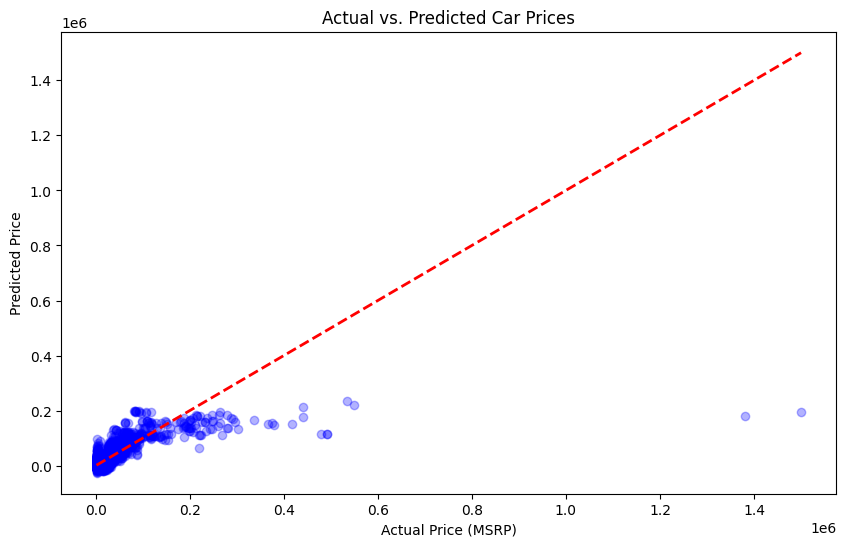

In [6]:
# Let's plot our predictions against the actual prices
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.3, color='blue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2, color='red')
plt.xlabel('Actual Price (MSRP)')
plt.ylabel('Predicted Price')
plt.title('Actual vs. Predicted Car Prices')
plt.show()